In [ ]:
%pip install ./requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: './requirements.txt': Expected package name at the start of dependency specifier
    ./requirements.txt
    ^


In [10]:
import pandas as pd
import duckdb
import numpy as np

conn = duckdb.connect()


In [ ]:
# Read the entire parquet file
df = pd.read_parquet("./data/faculty-salaries.parquet")

In [7]:
df.head()

,name,job,department,base,overtime,other,ual,benefitsee,benefitser,benefitsdc,notes,totalpay,totalbenefits,totalpaybenefits,year
0,No records found.,NaN,Allan Hancock College,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011
1,Miller Elizabeth,Assoc Supt/VP Admin Services,NaN,144823.00,0.0,47936.01,NaN,NaN,NaN,NaN,NaN,192759.01,24418.92,217177.93,2012
2,Bierly Gary,FT Faculty,NaN,96461.44,0.0,51841.35,NaN,NaN,NaN,NaN,NaN,148302.79,24710.55,173013.34,2012
3,Comstock Marie,FT Faculty,NaN,96461.04,0.0,45063.48,NaN,NaN,NaN,NaN,NaN,141524.52,21697.77,163222.29,2012
4,Sanchez Luis,Assoc Supt/VP Academic Affairs,NaN,135267.00,0.0,0.00,NaN,NaN,NaN,NaN,NaN,135267.00,23170.20,158437.20,2012


No rows with ual, benefitsee, benefitser, benefitsdc

In [16]:
df.count()

name                5345243
job                 5345131
department              137
base                5345131
overtime            5345131
other               5345131
ual                       0
benefitsee                0
benefitser                0
benefitsdc                0
notes                 28494
totalpay            5345115
totalbenefits       5345131
totalpaybenefits    5345128
year                5345243
dtype: int64

Some values have a total pay that is negative. Why is this? Should they just be removed? Also do we want to do any filtering on jobs? 

In [19]:
pay_less_than_0 = df[df['totalpay'] < 0]
pay_less_than_0.head()

,name,job,department,base,overtime,other,ual,benefitsee,benefitser,benefitsdc,notes,totalpay,totalbenefits,totalpaybenefits,year
2821,DAVID S HARMER,CARPENTER,NaN,-221.14,49.12,9.00,NaN,NaN,NaN,NaN,NaN,-163.02,0.0,-163.02,2011
3053,JOHN R SANDHAGEN,"EQUIPMENT TECHNICIAN I, SPECIALIZED EQUIPMENT",NaN,0.00,0.00,-153.79,NaN,NaN,NaN,NaN,NaN,-153.79,0.0,-153.79,2011
5525,JAMIE L CORLEY,ADMINISTRATIVE SUPPORT ASSISTANT -12 MONTH,NaN,-1991.79,0.00,0.00,NaN,NaN,NaN,NaN,NaN,-1991.79,0.0,-1991.79,2011
7789,THOMAS E HAWKINS,LECTURER - ACADEMIC YEAR,NaN,-114.45,0.00,0.00,NaN,NaN,NaN,NaN,NaN,-114.45,0.0,-114.45,2011
8408,ANDREA L BRAUNINGER,PHYSICIAN,NaN,-221.65,0.00,0.00,NaN,NaN,NaN,NaN,NaN,-221.65,0.0,-221.65,2011


In [20]:
rows_with_notes = df.dropna(subset=['notes'])
rows_with_notes.head()

,name,job,department,base,overtime,other,ual,benefitsee,benefitser,benefitsdc,notes,totalpay,totalbenefits,totalpaybenefits,year
150536,Leobigildo Cota Jr,Administrator I,NaN,9530.91,0.0,8.00,NaN,NaN,NaN,NaN,Employee holds multiple positions.,9538.91,3344.00,12882.91,2013
150590,Kathy A Fernandes,Administrator II,NaN,122687.68,0.0,35397.83,NaN,NaN,NaN,NaN,Employee holds multiple positions.,158085.51,47011.89,205097.40,2013
150591,Kathleen L Flachmeier,Administrator II,NaN,6276.18,0.0,27067.14,NaN,NaN,NaN,NaN,Employee holds multiple positions.,33343.32,2300.49,35643.81,2013
150636,Sabrina K Sanders,Administrator II,NaN,69412.61,0.0,60.00,NaN,NaN,NaN,NaN,Employee holds multiple positions.,69472.61,22435.71,91908.32,2013
150703,Robin D Innes,Administrator III,NaN,95384.96,0.0,1008.00,NaN,NaN,NaN,NaN,Employee holds multiple positions.,96392.96,27698.42,124091.38,2013


In [ ]:
#clean dataset, remove rows missing name or totalpay
clean_df = df.dropna(subset=['name', 'totalpay'])
#remove total pay under baseline salary (start 10,000)
clean_df = clean_df[clean_df['totalpay'] >= 10000]
clean_df.count()

name                3544483
job                 3544483
department               25
base                3544483
overtime            3544483
other               3544483
ual                       0
benefitsee                0
benefitser                0
benefitsdc                0
notes                 26018
totalpay            3544483
totalbenefits       3544483
totalpaybenefits    3544483
year                3544483
dtype: int64

In [14]:
col = df["totalpay"]

col.mean()                                         # center — sensitive
col.median()                                       # center — robust
col.std()    
col.min()
col.max()                                        # spread — sensitive
print("Mean:", col.mean())
print("Median:", col.median())
print("Standard Deviation:", col.std())
print("Minimum:", col.min())
print("Maximum:", col.max())
print("IQR:", col.quantile(0.75) - col.quantile(0.25))


Mean: 52426.11727489119
Median: 32719.0
Standard Deviation: 71412.07444136753
Minimum: -331742.0
Maximum: 7061667.0
IQR: 68102.015


In [27]:
result_df = duckdb.query("""
SELECT * from df
WHERE department != 'NaN' AND name != 'No records found.'
""").df()
result_df.head()
#result_df.count()

,name,job,department,base,overtime,other,ual,benefitsee,benefitser,benefitsdc,notes,totalpay,totalbenefits,totalpaybenefits,year
0,Laura Lee Hope,Interim Superintendent/president,President,359859.0,0.0,24000.0,NaN,NaN,NaN,NaN,None,383859.0,89833.0,473692.0,2024
1,Jacob Henry Knapp,General Counsel,President,253554.0,0.0,40693.0,NaN,NaN,NaN,NaN,None,294247.0,96414.0,390661.0,2024
2,Diana Galindo,"Vice President, Human Resources and Employee R...",Human Resources,272478.0,0.0,16578.0,NaN,NaN,NaN,NaN,None,289056.0,94957.0,384013.0,2024
3,Rodrigo Leonardo Garcia,"Vice President, Administrative Services","Vice President, Administrative Services",253554.0,0.0,26530.0,NaN,NaN,NaN,NaN,None,280084.0,96081.0,376165.0,2024
4,Val Martinez Garcia Jr,"Vice President, Student Services",Vice President - Student Services,253554.0,0.0,44631.0,NaN,NaN,NaN,NaN,None,298185.0,75268.0,373453.0,2024


In [30]:
result_df = duckdb.query("""
SELECT DISTINCT department from df
""").df()
result_df.head(10)
result_df.count()

department    86
dtype: int64

In [37]:
#join faculty-compensation.parquet with cal_poly_faculty.parquet (name = employee)


df1 = pd.read_parquet("./Data/faculty-compensation.parquet")
df2 = pd.read_parquet("./Data/cal_poly_faculty.parquet")


df_joined = pd.merge(
    df1,
    df2,
    left_on="employee",
    right_on="name",
    how="left"
)

df_joined.count()

employee           4985
FY 22-23           4985
FY 23-24           4985
FY 24-25           4985
name                152
year_hired          152
department          152
position            152
education           152
email               152
phone               152
catalog_section     152
name_raw            152
source_url          152
retrieved_at        152
dtype: int64

In [38]:
df1.head()

,employee,FY 22-23,FY 23-24,FY 24-25
0,"Abba, Michele M",62096.0,64516.60,67836.00
1,"Abdelhafeez, Laila Maher",0.0,0.00,42000.00
2,"Abdullah, Shahnaz T",0.0,91630.00,111562.00
3,"Abeloos, Diego V.",75807.0,97900.00,99228.00
4,"Abercromby, Kira Jorgensen",128576.0,134435.09,142673.48


In [39]:
df2.head()

,name,year_hired,department,position,education,email,phone,catalog_section,name_raw,source_url,retrieved_at
0,"Abdelhafeez, Laila M.",2025.0,Computer Science,Assistant Professor,"B.S., Cairo University, 2017; M.S., University...",,,Faculty Directory,"Abdelhafeez, Laila M. (2025) \nComputer Science",https://catalog.calpoly.edu/faculty-staff/,2026-09-15 05:06:23.673142+00:00
1,"Abercromby, Kira J.",2008.0,Aerospace Engineering,Professor,"B.S., University of California, Los Angeles, 1...",,,Faculty Directory,"Abercromby, Kira J. (2008) \nAerospace Enginee...",https://catalog.calpoly.edu/faculty-staff/,2026-09-15 05:06:23.673142+00:00
2,"Abeysiridara Samarakoon, Radhavi",2026.0,Civil and Environmental Engineering,Assistant Professor,"B.S., University of Moratuwa, Sir Lanka, 2014;...",,,Faculty Directory,"Abeysiridara Samarakoon, Radhavi (2026) \nCivi...",https://catalog.calpoly.edu/faculty-staff/,2026-09-15 05:06:23.673142+00:00
3,"Abo Ismail, Mohammed",2019.0,Animal Science,Associate Professor,"B.S., Alexandria University Damanhour, 2000; M...",,,Faculty Directory,"Abo Ismail, Mohammed (2019) \nAnimal Science",https://catalog.calpoly.edu/faculty-staff/,2026-09-15 05:06:23.673142+00:00
4,"Abril Valenzuela, Roberto",2026.0,Physics,Assistant Professor,"B.S., Physics, B.S., Mathematics, California P...",,,Faculty Directory,"Abril Valenzuela, Roberto (2026) \nPhysics",https://catalog.calpoly.edu/faculty-staff/,2026-09-15 05:06:23.673142+00:00


In [48]:
import pandas as pd

df1 = pd.read_parquet("./Data/faculty-compensation.parquet")
df2 = pd.read_parquet("./Data/cal_poly_faculty.parquet")

def split_name(df, source_column, prefix):
    parts = (
        df[source_column]
        .fillna("")
        .str.replace(r"[.,]", "", regex=True)
        .str.strip()
        .str.lower()
        .str.split()
    )

    df[f"{prefix}_first"] = parts.str[1]
    df[f"{prefix}_middle"] = parts.str[-1].where(parts.str.len() >= 3)
    df[f"{prefix}_last"] = parts.str[0]

split_name(df1, "employee", "employee")
split_name(df2, "name", "faculty")

df_joined = df1.merge(
    df2,
    left_on=["employee_first", "employee_last"],
    right_on=["faculty_first", "faculty_last"],
    how="left"
)

df_joined[[
    "employee_first", "employee_middle", "employee_last",
    "faculty_first", "faculty_middle", "faculty_last"
]].head()

,employee_first,employee_middle,employee_last,faculty_first,faculty_middle,faculty_last
0,michele,m,abba,NaN,NaN,NaN
1,laila,maher,abdelhafeez,laila,m,abdelhafeez
2,shahnaz,t,abdullah,NaN,NaN,NaN
3,diego,v,abeloos,NaN,NaN,NaN
4,kira,jorgensen,abercromby,kira,j,abercromby


In [49]:
df_joined.count()

employee           4985
FY 22-23           4985
FY 23-24           4985
FY 24-25           4985
employee_first     4985
employee_middle    4406
employee_last      4985
name                681
year_hired          679
department          681
position            681
education           681
email               681
phone               681
catalog_section     681
name_raw            681
source_url          681
retrieved_at        681
faculty_first       681
faculty_middle      329
faculty_last        681
dtype: int64

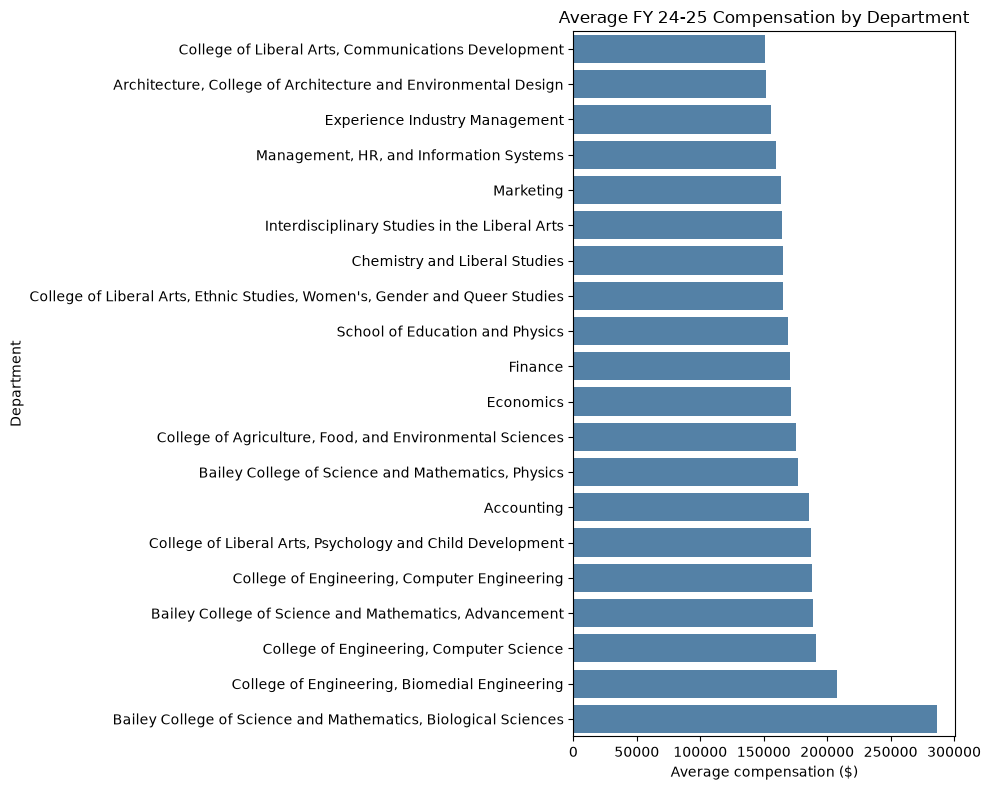

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

pay_column = "FY 24-25"
plot_df = df_joined[["department", pay_column]].copy()
plot_df[pay_column] = (
    plot_df[pay_column]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True)
    .replace("nan", pd.NA)
    .astype(float)
)
plot_df = plot_df.dropna(subset=["department", pay_column])

# Average pay by department; limit to the 20 departments with the most matched faculty.
department_pay = (
    plot_df.groupby("department", as_index=False)[pay_column]
    .mean()
    .nlargest(20, pay_column)
    .sort_values(pay_column)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=department_pay, x=pay_column, y="department", color="steelblue")
plt.title(f"Average {pay_column} Compensation by Department")
plt.xlabel("Average compensation ($)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()



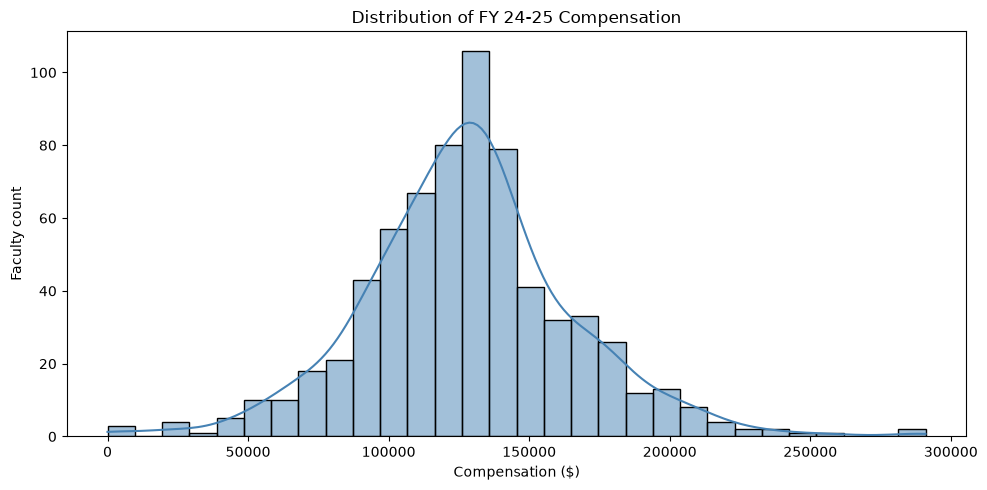

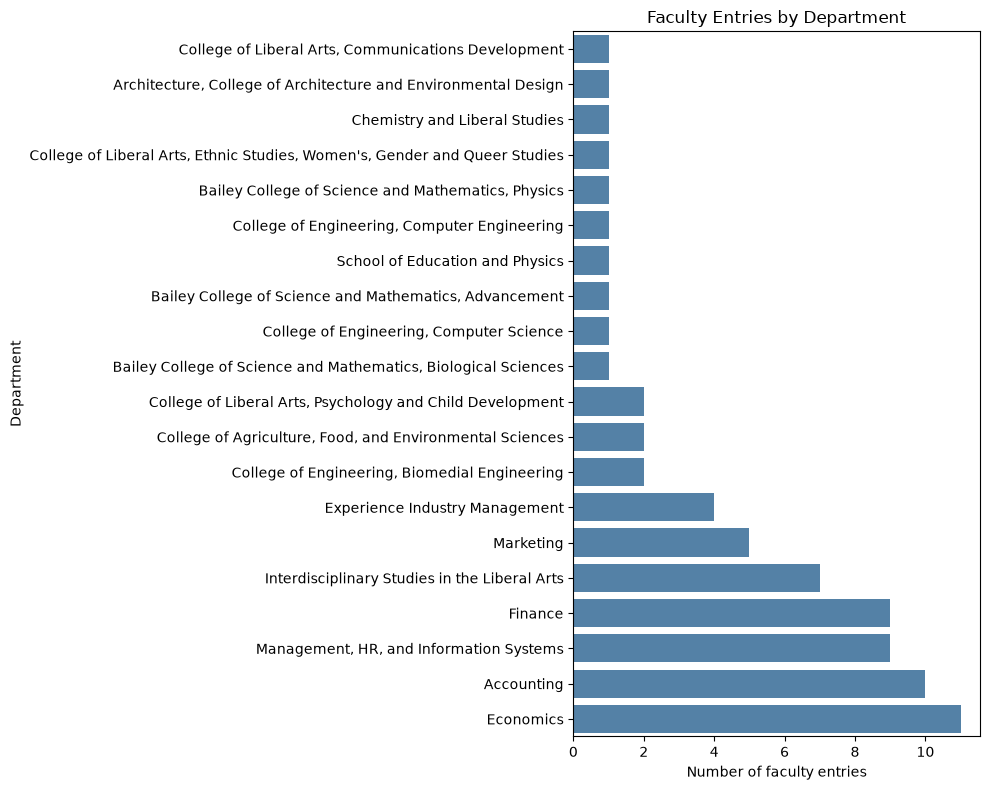

In [54]:
#plot of pay and count
# Overall pay distribution.
plt.figure(figsize=(10, 5))
sns.histplot(plot_df[pay_column], bins=30, kde=True, color="steelblue")
plt.title(f"Distribution of {pay_column} Compensation")
plt.xlabel("Compensation ($)")
plt.ylabel("Faculty count")
plt.tight_layout()
plt.show()

# Number of joined faculty entries in each department (top 20).
department_counts = (
    plot_df[plot_df["department"].isin(department_pay["department"])]
    ["department"]
    .value_counts()
    .reindex(department_pay["department"])
    .sort_values()
)
plt.figure(figsize=(10, 8))
sns.barplot(x=department_counts.values, y=department_counts.index, color="steelblue")
plt.title("Faculty Entries by Department")
plt.xlabel("Number of faculty entries")
plt.ylabel("Department")
plt.tight_layout()
plt.show()
